In [1]:
# SOURCE:
# https://github.com/nflverse/nflverse-data/releases
# https://github.com/nflverse/nfldata

# Comparison:
# https://www.nfeloapp.com/games/nfl-model-performance/#:~:text=About,models%20available%20on%20the%20internet.

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from datetime import datetime
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [3]:
print(sys.path)

['C:\\Users\\Eventh\\Documents\\GitHub\\PortfolioProject\\notebooks', 'C:\\ProgramData\\anaconda3\\python311.zip', 'C:\\ProgramData\\anaconda3\\DLLs', 'C:\\ProgramData\\anaconda3\\Lib', 'C:\\ProgramData\\anaconda3', '', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\Pythonwin']


In [4]:
os.getcwd()

'C:\\Users\\Eventh\\Documents\\GitHub\\PortfolioProject\\notebooks'

In [5]:
path = os.path.normpath(os.getcwd() + os.sep + os.pardir)

In [6]:
print(path)

C:\Users\Eventh\Documents\GitHub\PortfolioProject


In [7]:
df = pd.read_csv(path + "/data/raw/games.csv", sep=",")
pd.set_option("display.max_columns", 200) # set max columns to 200, so df.head() shows all(max 200) columns    
# rename qb columns
df = df.rename(columns={"away_qb_name": "away_qb", "home_qb_name": "home_qb"})
df.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb,home_qb,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,14.0,Home,-3.0,31.0,0.0,1999091210,598.0,NaN,199909120atl,NaN,190912001,NaN,7,7,NaN,NaN,-4.0,NaN,NaN,49.0,NaN,NaN,0,dome,astroturf,NaN,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,20.0,Home,3.0,37.0,0.0,1999091206,597.0,NaN,199909120chi,NaN,190912003,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,38.0,NaN,NaN,0,outdoors,grass,80.0,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,0.0,Home,-43.0,43.0,0.0,1999091213,604.0,NaN,199909120cle,NaN,190912005,NaN,7,7,NaN,NaN,-6.0,NaN,NaN,37.0,NaN,NaN,1,outdoors,grass,78.0,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,28.0,Home,4.0,52.0,0.0,1999091208,602.0,NaN,199909120gnb,NaN,190912009,NaN,7,7,NaN,NaN,9.0,NaN,NaN,43.0,NaN,NaN,0,outdoors,grass,67.0,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,31.0,Home,17.0,45.0,0.0,1999091202,591.0,NaN,199909120clt,NaN,190912011,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,45.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [8]:
# Cleaning function
def clean_df(df, start_season=2000):
    # ---------- DROP COLUMNS AND ROWS ---------- 
    # we will drop additional columns later with an extra function, because we need them to create additional features
    # drop bet related columns
    # we also drop the scores, totals and results after creating our target "win".
    df = df.drop(columns=['away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
                          'home_spread_odds', 'total_line', 'under_odds', 'over_odds'])
    # drop double columns
    df = df.drop(columns=['away_qb_id', 'home_qb_id', 'stadium_id'])
    
    # select starting season via start_season
    # all missing gametimes are in the '99 season, so we set start_seasons default to 2000, to drop atleast the 1999 season
    df = df.loc[df['season'] >= start_season, :]
    df = df.reset_index(drop=True)
    
    # ---------- CREATE NEW COLUMNS ---------- 
    # check the current date
    now = datetime.now()
    # fill NaNs in gametime, so we can convert to datetime
    df["gametime"] = df["gametime"].fillna("11:11")
    # convert gameday and gametime to datetime 
    df['gameday'] = pd.to_datetime(df['gameday'])
    df['gametime'] = pd.to_datetime(df['gametime'], format="%H:%M")
    # extract hour and minute from the gametime
    df["starting_hour"] = df.loc[:, "gametime"].dt.hour
    # convert gametime to string only showing "HH:MM"
    df['gametime'] = df['gametime'].dt.strftime("%H:%M")
    # combine both columns to get gameday + gametime as one, so we can compare it to now
    df['datetime'] = pd.to_datetime(df['gameday'].astype(str) + ' ' + df['gametime'])
    # replace our imputation value with NaNs again
    df["gametime"] = df["gametime"].replace("11:11:00", np.nan)
    # filter rows where "datetime" is greater than "now" to drop future games
    df = df[df['datetime'] < now]
    # create month column
    df["month"] = df["gameday"].dt.month
    # create target column "win"
    # np.where(condition = df["result"] > 0, then = 1, else = 0)
    df["win"] = np.where(df["result"] > 0, 1, 0)

    # ---------- IMPUTATION OF TEAMS ---------- 
    # merge old with new team names
    # OLD - NEW Team name
    # OAK (Oakland Raiders) - LV (Las Vegas Raiders) 
    # SD (San Diego Chargers) - LAC (Los Angeles Chargers)
    # STL (St. Louis Rams) - LA (Los Angeles Rams)
    team_cols = ["away_team", "home_team"]
    for col in team_cols:
        df.loc[:, col] = df.loc[:, col].replace({"OAK": "LV", 
                                                "SD": "LAC", 
                                                "STL": "LA"})
      
    # ---------- IMPUTATION OF SURFACE ---------- 
    # everything else than grass is synthetic or hybrid grass
    # combine all synthetic and hybrid under 'synthetic'
    # combine both grass
    df.loc[:, "surface"] = df.loc[:, "surface"].replace(["fieldturf", "astroturf", "sportturf", "matrixturf", "astroplay", "a_turf", "dessograss"], "synthetic")
    df.loc[:, "surface"] = df.loc[:, "surface"].replace("grass ", "grass")

    # get array of all stadiums that contain NaNs in surface column
    surface_nan = df.loc[df["surface"].isna(), "stadium"].unique()
    # first fill NaNs with "Unkown", so we dont get errors while using .mode() with NaNs
    df["surface"] = df["surface"].fillna("Unkown")
    for stadium in surface_nan:
        surface_mode = df.loc[df["stadium"] == stadium, "surface"].mode()[0]
        # if the mode of the surface is "Unkown", we dont have enough data for the given stadium, therefore we impute with the overall mode surface of all stadiums
        if surface_mode == "Unkown":
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].mode()[0]
        # if we have enough data for the given stadium, we impute with the mode surface of the given stadium
        else:
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].replace("Unkown", surface_mode)
    # replace "Unkown" surface with NaNs again, so its easier to spot missed imputations
    df["surface"] = df["surface"].replace("Unkown", np.nan)

    # ---------- IMPUTATION OF TEMPERATURE & WIND ---------- 
    # wind [mph] - 71 mph x 1.609 = 114.263 kmh
    # temp [°F] - (109 °F − 32) × 5/9 = 42.778 °C
    # web crawling for weather: https://www.wunderground.com/history
    # create crosstabs of the median value of temperate & wind for each month in each stadium for future imputation
    ct_temp = pd.crosstab(df["month"], df["stadium"], values=df["temp"], aggfunc="median", dropna=False)
    ct_wind = pd.crosstab(df["month"], df["stadium"], values=df["wind"], aggfunc="median", dropna=False) 
    # get array of all stadiums that contain NaNs in temp & wind column
    temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
    wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()           
    
    # iterate through the left NaNs in temp
    for stadium in temp_nan:
        # try to imputate by the monthly median temp for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].fillna(ct_temp.loc[month, stadium])  
        # if there are still NaNs left, imputate by the overall median temp for each stadium
        df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())
    
    # iterate through the left NaNs in wind  
    for stadium in wind_nan:
        # try to imputate by the monthly median wind for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"].fillna(ct_wind.loc[month, stadium])   
        # if there are still NaNs left, imputate by the overall median wind for each stadium
        df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())
    
    # left out cities gathered by hand
    # looking for data at: https://www.wunderground.com/history/monthly/us/tx/dallas/date/2020-11
    # we will use the average temperate of 2020-11 at the given state
    # FUTURE: web crawling
    city_temp_wind = {"DAL": [61.2, 7.8],
                      "NO": [61.2, 7.6],
                      "LV": [61.2, 6.3],
                      "TB": [61.2, 7.7],
                      "LA": [61.2, 3.5],
                      "LAC": [61.2, 3.5],
                      "DET": [61.2, 9.8],
                      "ATL": [61.2, 8.4],
                      "MIN": [61.2, 8.9],
                      "IND": [61.2, 10.84],
                      "HOU": [61.2, 7.8],
                      "BUF": [61.2, 12.3],
                      "ARI": [61.2, 4.7]}
    
    for city, value in city_temp_wind.items():
        # select the most played stadium of the home team, we also imputate the location = "Neutral" games
        # this can lead to errors as we don't take into account the potential relocation of a team
        df.loc[df["home_team"] == city, "temp"] = df.loc[df["home_team"] == city, "temp"].fillna(value[0])
        df.loc[df["home_team"] == city, "wind"] = df.loc[df["home_team"] == city, "wind"].fillna(value[1])
        
    # get array of all stadiums that contain NaNs in temp & wind column
    temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
    wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()     
    
    for stadium in temp_nan:
        df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())
    for stadium in wind_nan:
        df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())
    
    # ---------- IMPUTATION OF QB's ---------- 
    # done by hand for now
    # https://www.nfl.com/games/patriots-at-colts-2021-reg-15
    # FUTURE: web crawling
    missing_qbs = [["Russel Wilson", "Patrick Mahomes"],
                   ["Lamar Jackson", "Ryan Tannehill"],
                   ["Sam Howell", "Desmond Ridder"],
                   ["Kirk Cousins"," Tyson Bagent"],
                   ["Geno Smith", "Joe Burrow"],
                   ["Derek Carr", "C.J. Stroud"],
                   ["Gardner Minshew", "Trevor Lawrence"],
                   ["Bryce Young", "Tua Tagovailoa"]]

    k = 0
    for i in range(6240, 6249):
        if i == 6245:
            k += 1
        df.loc[i, "away_qb"] = missing_qbs[i-6240-k][0]
        df.loc[i, "home_qb"] = missing_qbs[i-6240-k][1]
        
    # ---------- IMPUTATION OF REFEREES ---------- 
    # done by hand for now
    # FUTURE: web crawling
    # Carl Cheffers - https://www.espn.com/nfl/game?gameId=401326540&_slug_=patriots-colts
    df.loc[5802, "referee"] = "Carl Cheffers"
    df.loc[6442, "referee"] = "Bill Vinovich"
    df.loc[6443, "referee"] = "Shawn Hochuli"

    # ----- IMPORTANT ------
    # maybe keep espn-id to crawl data from - https://www.espn.com/nfl/game?gameId=401326540
    # same for pfr - https://www.pro-football-reference.com/boxscores/199909120atl.htm
    #
    # https://www.ftnfantasy.com/nfl/game-logs?page=ForLogsView&teamAbbv=ATL&year=2023 - for web crawling
    # https://www.footballdb.com/games/boxscore/miami-dolphins-vs-kansas-city-chiefs-2024011302
    # https://www.footballdb.com/teams/nfl/arizona-cardinals/seasons

    return df

In [9]:
df_clean = clean_df(df)

In [10]:
df_clean.isna().sum()

game_id             0
season              0
game_type           0
week                0
gameday             0
weekday             0
gametime            0
away_team           0
away_score          0
home_team           0
home_score          0
location            0
result              0
total               0
overtime            0
old_game_id         0
gsis                0
nfl_detail_id    6172
pfr                 0
pff              2152
espn                0
ftn              5340
away_rest           0
home_rest           0
div_game            0
roof                0
surface             0
temp                0
wind                0
away_qb             0
home_qb             0
away_coach          0
home_coach          0
referee             0
stadium             0
starting_hour       0
datetime            0
month               0
win                 0
dtype: int64

In [11]:
df_clean.describe()

,season,week,gameday,away_score,home_score,result,total,overtime,old_game_id,gsis,pff,espn,ftn,away_rest,home_rest,div_game,temp,wind,starting_hour,datetime,month,win
count,6444.000000,6444.000000,6444,6444.000000,6444.000000,6444.000000,6444.000000,6444.000000,6.444000e+03,6444.000000,4292.000000,6.444000e+03,1104.000000,6444.000000,6444.000000,6444.000000,6444.000000,6444.000000,6444.000000,6444,6444.000000,6444.000000
mean,2011.610956,9.565798,2012-06-19 09:35:51.955307264,20.939168,23.265829,2.326660,44.204997,0.061918,2.011786e+09,44514.517536,6197.638164,3.235990e+08,5610.425725,7.481378,7.514742,0.373526,58.861375,8.298035,14.925978,2012-06-20 00:39:47.169459968,9.880043,0.563625
min,2000.000000,1.000000,2000-09-03 00:00:00,0.000000,0.000000,-49.000000,3.000000,0.000000,2.000090e+09,987.000000,731.000000,2.009030e+08,5058.000000,4.000000,4.000000,0.000000,-6.000000,0.000000,9.000000,2000-09-03 13:00:00,1.000000,0.000000
25%,2006.000000,5.000000,2006-09-17 00:00:00,14.000000,16.000000,-7.000000,34.000000,0.000000,2.006092e+09,28885.750000,2062.750000,2.609170e+08,5334.750000,7.000000,7.000000,0.000000,51.000000,5.000000,13.000000,2006-09-17 15:18:45,9.000000,0.000000
50%,2012.000000,10.000000,2012-09-23 00:00:00,20.000000,23.000000,3.000000,43.500000,0.000000,2.012092e+09,55537.500000,3415.500000,3.209230e+08,5610.500000,7.000000,7.000000,0.000000,61.200000,8.000000,13.000000,2012-09-23 13:00:00,10.000000,1.000000
75%,2018.000000,14.000000,2018-09-23 00:00:00,27.000000,30.000000,11.000000,53.000000,0.000000,2.018092e+09,57609.250000,9352.250000,4.010307e+08,5886.250000,7.000000,7.000000,1.000000,66.000000,10.000000,16.000000,2018-09-23 13:46:15,12.000000,1.000000
max,2023.000000,22.000000,2024-01-21 00:00:00,59.000000,70.000000,59.000000,106.000000,1.000000,2.024012e+09,59503.000000,21536.000000,4.015478e+08,6163.000000,21.000000,16.000000,1.000000,109.000000,71.000000,23.000000,2024-01-21 18:30:00,12.000000,1.000000
std,6.943796,5.316976,NaN,10.058745,10.317027,14.628396,14.186220,0.241025,6.961220e+06,17238.100125,6075.412083,7.301061e+07,319.042811,1.994201,2.095634,0.483777,14.712699,4.741760,2.699546,NaN,2.735147,0.495974


In [12]:
#sns.pairplot(df)

In [13]:
# ----- IMPORTANT ------
# maybe keep espn-id to crawl data from - https://www.espn.com/nfl/game?gameId=401326540
# same for pfr - https://www.pro-football-reference.com/boxscores/199909120atl.htm
#
# https://www.ftnfantasy.com/nfl/game-logs?page=ForLogsView&teamAbbv=ATL&year=2023 - for web crawling
# https://www.footballdb.com/games/boxscore/miami-dolphins-vs-kansas-city-chiefs-2024011302
# https://www.footballdb.com/teams/nfl/arizona-cardinals/seasons

In [14]:
# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

<Axes: >

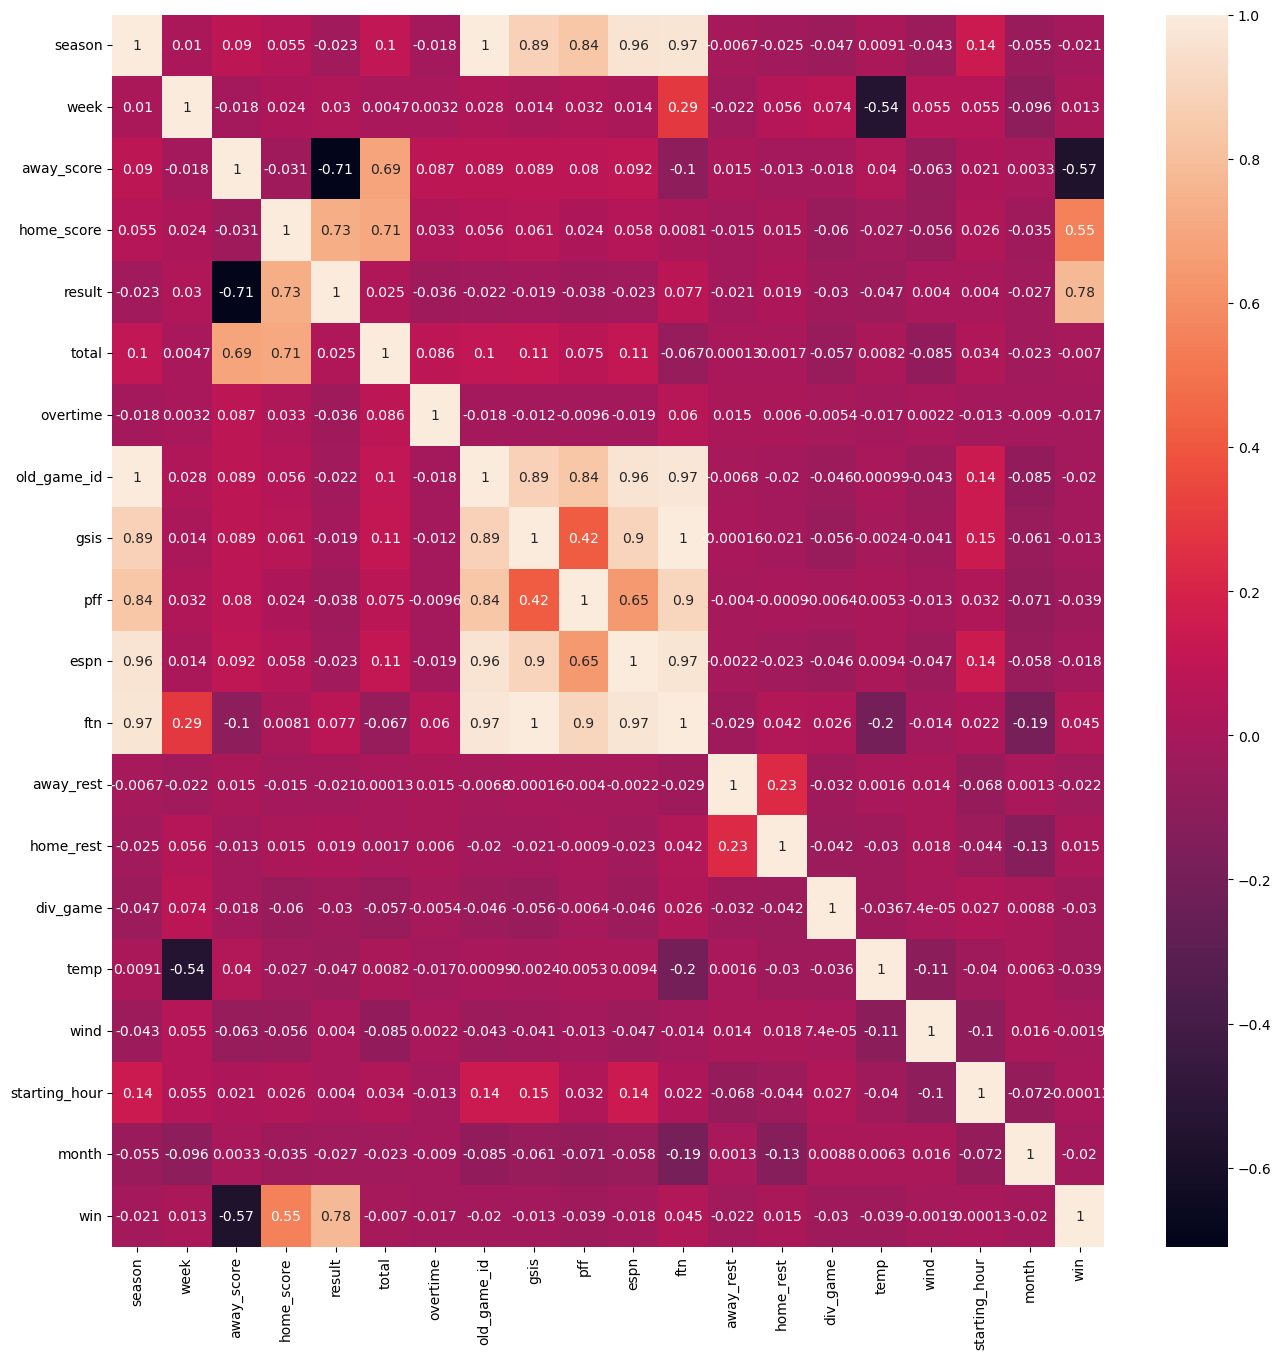

In [15]:
fig, ax = plt.subplots(figsize=(16, 16))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, ax=ax)

In [16]:
# for the future:
# function to display win percentage by chosen type and value
# e.g. Type = team (columns = away_team & home_team), value = "IND" shows win percantage of the Indianapolis Colts

In [17]:
df_clean.groupby("win")["season"].count()

win
0    2812
1    3632
Name: season, dtype: int64

In [18]:
# split into train & test set
df_train = df_clean.loc[df_clean["season"] < 2020, :]
df_test = df_clean.loc[df_clean["season"] >= 2020, :]

In [19]:
df_train.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb,home_qb,away_coach,home_coach,referee,stadium,starting_hour,datetime,month,win
0,2000_01_SF_ATL,2000,REG,1,2000-09-03,Sunday,13:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,2000090310,998.0,NaN,200009030atl,NaN,200903001,NaN,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,13,2000-09-03 13:00:00,9,1
1,2000_01_JAX_CLE,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,2000090306,994.0,NaN,200009030cle,NaN,200903005,NaN,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,13,2000-09-03 13:00:00,9,0
2,2000_01_IND_KC,2000,REG,1,2000-09-03,Sunday,13:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,2000090305,993.0,NaN,200009030kan,NaN,200903012,NaN,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,13,2000-09-03 13:00:00,9,0
3,2000_01_CHI_MIN,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,2000090303,991.0,NaN,200009030min,NaN,200903016,NaN,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,13,2000-09-03 13:00:00,9,1
4,2000_01_TB_NE,2000,REG,1,2000-09-03,Sunday,13:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,2000090312,1000.0,NaN,200009030nwe,NaN,200903017,NaN,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,13,2000-09-03 13:00:00,9,0


In [20]:
# dictionary with coaches [Total Games - W/L Ratio - Games with Team]
# dictionary with qbs [Total Games - W/L Ratio - Games with Team]

In [21]:
for col in df_train.columns:
    print(col, df_train[col].nunique())

game_id 5324
season 20
game_type 5
week 21
gameday 1002
weekday 7
gametime 48
away_team 32
away_score 55
home_team 32
home_score 59
location 2
result 98
total 92
overtime 2
old_game_id 5324
gsis 5324
nfl_detail_id 0
pfr 5324
pff 3738
espn 5312
ftn 266
away_rest 12
home_rest 11
div_game 2
roof 4
surface 2
temp 103
wind 46
away_qb 253
home_qb 243
away_coach 136
home_coach 136
referee 82
stadium 87
starting_hour 13
datetime 2174
month 6
win 2


In [22]:
# feature engineering
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [23]:
df_clean.columns
# columns to use for baseline model: 
# ['season', 'game_type', 'week', 'weekday','away_team', 'away_score', 'home_team', 'home_score', 'location', 'overtime', 
#  'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 'gametime_h', 'gametime_min']

Index(['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday',
       'gametime', 'away_team', 'away_score', 'home_team', 'home_score',
       'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
       'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb', 'home_qb',
       'away_coach', 'home_coach', 'referee', 'stadium', 'starting_hour',
       'datetime', 'month', 'win'],
      dtype='object')

In [24]:
df_base = df_clean[['season', 'game_type', 'week', 'away_team', 'home_team', 'location', 
              'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 
              'win']]
df_base.head()

,season,game_type,week,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,REG,1,SF,ATL,Home,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,REG,1,JAX,CLE,Home,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,REG,1,IND,KC,Home,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,REG,1,CHI,MIN,Home,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,REG,1,TB,NE,Home,7,7,0,outdoors,grass,71.0,5.0,0


In [25]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6444 entries, 0 to 6443
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     6444 non-null   int64  
 1   game_type  6444 non-null   object 
 2   week       6444 non-null   int64  
 3   away_team  6444 non-null   object 
 4   home_team  6444 non-null   object 
 5   location   6444 non-null   object 
 6   away_rest  6444 non-null   int64  
 7   home_rest  6444 non-null   int64  
 8   div_game   6444 non-null   int64  
 9   roof       6444 non-null   object 
 10  surface    6444 non-null   object 
 11  temp       6444 non-null   float64
 12  wind       6444 non-null   float64
 13  win        6444 non-null   int32  
dtypes: float64(2), int32(1), int64(5), object(6)
memory usage: 988.0+ KB


In [26]:
# split df_base into train & test set
df_base_train = df_base.loc[df_base["season"] < 2020]
df_base_test = df_base.loc[df_base["season"] >= 2020]

# split further into features & target
features_base_train = df_base_train.drop(columns="win")
target_base_train = df_base_train["win"]
features_base_test = df_base_test.drop(columns="win")
target_base_test = df_base_test["win"]

In [27]:
df_base_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5324 entries, 0 to 5323
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     5324 non-null   int64  
 1   game_type  5324 non-null   object 
 2   week       5324 non-null   int64  
 3   away_team  5324 non-null   object 
 4   home_team  5324 non-null   object 
 5   location   5324 non-null   object 
 6   away_rest  5324 non-null   int64  
 7   home_rest  5324 non-null   int64  
 8   div_game   5324 non-null   int64  
 9   roof       5324 non-null   object 
 10  surface    5324 non-null   object 
 11  temp       5324 non-null   float64
 12  wind       5324 non-null   float64
 13  win        5324 non-null   int32  
dtypes: float64(2), int32(1), int64(5), object(6)
memory usage: 603.1+ KB


In [28]:
df_base_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1120 entries, 5324 to 6443
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     1120 non-null   int64  
 1   game_type  1120 non-null   object 
 2   week       1120 non-null   int64  
 3   away_team  1120 non-null   object 
 4   home_team  1120 non-null   object 
 5   location   1120 non-null   object 
 6   away_rest  1120 non-null   int64  
 7   home_rest  1120 non-null   int64  
 8   div_game   1120 non-null   int64  
 9   roof       1120 non-null   object 
 10  surface    1120 non-null   object 
 11  temp       1120 non-null   float64
 12  wind       1120 non-null   float64
 13  win        1120 non-null   int32  
dtypes: float64(2), int32(1), int64(5), object(6)
memory usage: 126.9+ KB


In [29]:
df_base_test

,season,game_type,week,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
5324,2020,REG,1,HOU,KC,Home,7,7,0,outdoors,grass,56.0,7.0,1
5325,2020,REG,1,SEA,ATL,Home,7,7,0,closed,synthetic,61.2,8.4,0
5326,2020,REG,1,CLE,BAL,Home,7,7,1,outdoors,grass,76.0,5.0,1
5327,2020,REG,1,NYJ,BUF,Home,7,7,1,outdoors,synthetic,67.0,15.0,1
5328,2020,REG,1,LV,CAR,Home,7,7,0,outdoors,grass,81.0,5.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6439,2023,WC,19,PHI,TB,Home,8,8,0,outdoors,grass,65.0,2.0,1
6440,2023,DIV,20,HOU,BAL,Home,7,14,0,outdoors,grass,27.0,16.0,1
6441,2023,DIV,20,GB,SF,Home,6,13,0,outdoors,grass,59.0,8.0,1
6442,2023,DIV,20,TB,DET,Home,6,7,0,dome,synthetic,61.2,9.8,1


In [30]:
# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train.select_dtypes(exclude=[np.number]).columns

In [31]:
ohe = OneHotEncoder()
features_base_train_ohe = pd.DataFrame(ohe.fit_transform(features_base_train[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

In [32]:
features_base_train_ohe

,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5319,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5320,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5321,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5322,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [33]:
scaler = StandardScaler()
features_base_train_scaled = pd.DataFrame(scaler.fit_transform(features_base_train[num_cols]), columns=num_cols)
features_base_train_scaled.head()

,season,week,away_rest,home_rest,div_game,temp,wind
0,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,0.153364,0.013511
1,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,1.286128,-0.486579
2,-1.655814,-1.614715,-0.249337,-0.248942,-0.779727,2.095246,-0.694949
3,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,0.153364,0.117697
4,-1.655814,-1.614715,-0.249337,-0.248942,-0.779727,0.814143,-0.694949


In [34]:
features_base_train_enc = pd.concat([features_base_train_scaled, features_base_train_ohe], axis=1, join="inner")

In [35]:
features_base_train_enc.head()

,season,week,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,0.153364,0.013511,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,1.286128,-0.486579,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-1.655814,-1.614715,-0.249337,-0.248942,-0.779727,2.095246,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,0.153364,0.117697,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.655814,-1.614715,-0.249337,-0.248942,-0.779727,0.814143,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [36]:
features_base_test_ohe = pd.DataFrame(ohe.transform(features_base_test[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_scaled = pd.DataFrame(scaler.transform(features_base_test[num_cols]), columns=num_cols)
features_base_test_enc = pd.concat([features_base_test_scaled, features_base_test_ohe], axis=1, join="inner")

In [37]:
features_base_test_enc.head()

,season,week,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,1.820213,-1.614715,-0.249337,-0.248942,-0.779727,-0.197254,-0.278208,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.820213,-1.614715,-0.249337,-0.248942,-0.779727,0.153364,0.013511,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.820213,-1.614715,-0.249337,-0.248942,1.282501,1.151275,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.820213,-1.614715,-0.249337,-0.248942,1.282501,0.544437,1.388758,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.820213,-1.614715,-0.249337,-0.248942,-0.779727,1.488408,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [38]:
target_base_test.value_counts()

win
1    600
0    520
Name: count, dtype: int64

In [39]:
model_dt = DecisionTreeClassifier(max_depth=20)
model_dt.fit(features_base_train_enc, target_base_train)
target_base_test_pred = model_dt.predict(features_base_test_enc)

print("-----DecisionTree | Depth=20-----")
print(classification_report(target_base_test, target_base_test_pred))

-----DecisionTree | Depth=20-----
              precision    recall  f1-score   support

           0       0.45      0.19      0.27       520
           1       0.53      0.80      0.64       600

    accuracy                           0.52      1120
   macro avg       0.49      0.50      0.46      1120
weighted avg       0.50      0.52      0.47      1120



In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [41]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_log_one.predict(features_base_test_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))                                             

-----LogReg-----
Best Parameter: {'C': 10, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.49      0.32      0.39       520
           1       0.55      0.71      0.62       600

    accuracy                           0.53      1120
   macro avg       0.52      0.51      0.50      1120
weighted avg       0.52      0.53      0.51      1120



In [42]:
from sklearn.metrics import fbeta_score, make_scorer

In [43]:
ftwo_scorer = make_scorer(fbeta_score, beta=0.3)

search_space_rf = {'max_depth': np.geomspace(start=5, stop=200, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_one = GridSearchCV(DecisionTreeClassifier(),
                            search_space_rf,
                            cv=5,
                            scoring=ftwo_scorer,
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_dtc_one.predict(features_base_test_enc)
# Print Metrics
print("-----DecisionTree | FBeta=0.3-----")
print("Best Parameter: {}".format(grid_dtc_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))                                             

-----DecisionTree | FBeta=0.3-----
Best Parameter: {'max_depth': 23, 'min_samples_leaf': 62}
              precision    recall  f1-score   support

           0       0.46      0.26      0.33       520
           1       0.54      0.74      0.62       600

    accuracy                           0.52      1120
   macro avg       0.50      0.50      0.48      1120
weighted avg       0.50      0.52      0.49      1120



In [44]:
search_space_rf = {'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_one = GridSearchCV(DecisionTreeClassifier(max_depth=50),
                            search_space_rf,
                            cv=5,
                            scoring="precision",
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_dtc_one.predict(features_base_test_enc)
# Print Metrics
print("-----DecisionTree-----")
print("Best Parameter: {}".format(grid_dtc_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))     

-----DecisionTree-----
Best Parameter: {'min_samples_leaf': 62}
              precision    recall  f1-score   support

           0       0.47      0.63      0.54       520
           1       0.54      0.39      0.45       600

    accuracy                           0.50      1120
   macro avg       0.51      0.51      0.49      1120
weighted avg       0.51      0.50      0.49      1120



In [45]:
from sklearn.ensemble import RandomForestClassifier

search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = model_rf.predict(features_base_test_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 71, 'min_samples_leaf': 3}
              precision    recall  f1-score   support

           0       0.51      0.36      0.42       520
           1       0.56      0.70      0.62       600

    accuracy                           0.54      1120
   macro avg       0.53      0.53      0.52      1120
weighted avg       0.54      0.54      0.53      1120



In [46]:
fi = model_rf.best_estimator_.feature_importances_

feature_importance = pd.Series(fi, index=features_base_test_enc.columns)

In [47]:
feature_importance.sort_values(ascending=False)[:20]

season           0.121478
temp             0.109425
week             0.101741
wind             0.095110
home_rest        0.041394
away_rest        0.041132
away_team_NE     0.021417
home_team_NE     0.020376
div_game         0.019091
home_team_CLE    0.012868
away_team_CLE    0.012171
surface_grass    0.011496
away_team_PHI    0.011041
away_team_PIT    0.010061
home_team_BAL    0.009503
away_team_NO     0.008698
home_team_GB     0.008592
away_team_IND    0.008543
home_team_DET    0.008366
away_team_DET    0.008202
dtype: float64

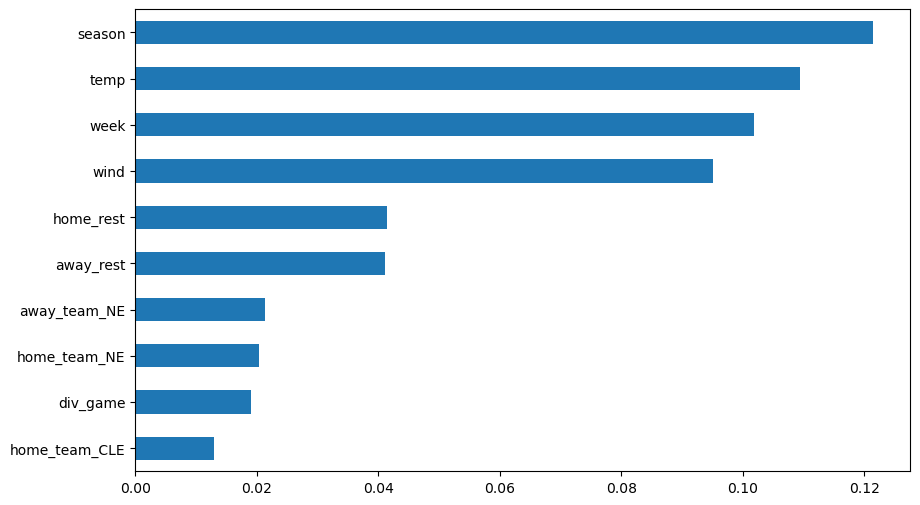

In [48]:
feature_importance.sort_values(ascending=False)[:10].plot(kind='barh', figsize=(10, 6)).invert_yaxis()

In [49]:
def create_points(df, week_change=100, return_dict=False):
    # week_change: sets the week from which the season stats are used and no longer the overall stats. if week_change = -1, only the overall stats are used
    df["away_avg_points"] = 0
    df["away_avg_points_allowed"] = 0
    df["home_avg_points"] = 0
    df["home_avg_points_allowed"] = 0
    
    # FUTURE: create a function to calculate the average of the last x seasons
    
    current_season = df.iloc[0]['season']
    # Create two dictionaries for each team, one for overall points and one for season points
    team_points_overall = {team: {"avg_points": 0, 
                                  "avg_points_allowed": 0, 
                                  "points": 0, 
                                  "points_allowed": 0, 
                                  "games_played": 0} for team in set(df['away_team']).union(set(df['home_team']))}
    season_dict = {}
    for season in df["season"].unique():
        season_dict[season] = {team: {"avg_points": 0, 
                                      "avg_points_allowed": 0, 
                                      "points": 0, 
                                      "points_allowed": 0, 
                                      "games_played": 0} for team in set(df['away_team']).union(set(df['home_team']))}
     
    for index, row in df.iterrows():
        season = row['season']
        week = row["week"]
        
        # If we've reached a new season, reset season stats
        if season != current_season:
            current_season = season
    
        away_team = row['away_team']
        home_team = row['home_team']
        away_points = row["away_score"]
        home_points = row["home_score"]
        
        # Assign the current points to the DataFrame before they are updated
        # check for week_change, if reached, use season stats instead of overall stats
        if week >= week_change:
            df.at[index, 'away_avg_points'] = season_dict[current_season][away_team]["avg_points"]
            df.at[index, 'away_avg_points_allowed'] = season_dict[current_season][away_team]["avg_points_allowed"]
            df.at[index, 'home_avg_points'] = season_dict[current_season][home_team]["avg_points"]
            df.at[index, 'home_avg_points_allowed'] = season_dict[current_season][home_team]["avg_points_allowed"]
        else:
            df.at[index, 'away_avg_points'] = team_points_overall[away_team]["avg_points"]
            df.at[index, 'away_avg_points_allowed'] = team_points_overall[away_team]["avg_points_allowed"]
            df.at[index, 'home_avg_points'] = team_points_overall[home_team]["avg_points"]
            df.at[index, 'home_avg_points_allowed'] = team_points_overall[home_team]["avg_points_allowed"]
        
            
        
        # Set new points for overall stats
        # AWAY
        team_points_overall[away_team]["games_played"] += 1
        team_points_overall[away_team]["points"] += away_points
        team_points_overall[away_team]["points_allowed"] += home_points
        team_points_overall[away_team]["avg_points"] = team_points_overall[away_team]["points"] / team_points_overall[away_team]["games_played"]
        team_points_overall[away_team]["avg_points_allowed"] = team_points_overall[away_team]["points_allowed"] / team_points_overall[away_team]["games_played"]        
        # HOME
        team_points_overall[home_team]["games_played"] += 1
        team_points_overall[home_team]["points"] += home_points
        team_points_overall[home_team]["points_allowed"] += away_points
        team_points_overall[home_team]["avg_points"] = team_points_overall[home_team]["points"] / team_points_overall[home_team]["games_played"]
        team_points_overall[home_team]["avg_points_allowed"] = team_points_overall[home_team]["points_allowed"] / team_points_overall[home_team]["games_played"]  
        
        # Set new points for season stats
        # AWAY
        season_dict[current_season][away_team]["games_played"] += 1
        season_dict[current_season][away_team]["points"] += away_points
        season_dict[current_season][away_team]["points_allowed"] += home_points
        season_dict[current_season][away_team]["avg_points"] = season_dict[current_season][away_team]["points"] / season_dict[current_season][away_team]["games_played"]
        season_dict[current_season][away_team]["avg_points_allowed"] = season_dict[current_season][away_team]["points_allowed"] / season_dict[current_season][away_team]["games_played"]        
        # HOME
        season_dict[current_season][home_team]["games_played"] += 1
        season_dict[current_season][home_team]["points"] += home_points
        season_dict[current_season][home_team]["points_allowed"] += away_points
        season_dict[current_season][home_team]["avg_points"] = season_dict[current_season][home_team]["points"] / season_dict[current_season][home_team]["games_played"]
        season_dict[current_season][home_team]["avg_points_allowed"] = season_dict[current_season][home_team]["points_allowed"] / season_dict[current_season][home_team]["games_played"]
    
    if return_dict == True:
        return df, season_dict
    return df

In [50]:
df_point_test = df_clean.copy()
df_point_test = create_points(df_point_test)

In [51]:
def create_elo_rating(df, alpha = 0):
    # Initialize the DataFrame with Elo score columns
    df['away_elo'] = 0
    df['home_elo'] = 0
    df["away_qb_elo"] = 0
    df["home_qb_elo"] = 0
    df["away_coach_elo"] = 0
    df["home_coach_elo"] = 0
    
    # Function to calculate the expected score
    def expected_score(Ra, Rb):
        return 1 / (1 + 10 ** ((Rb - Ra) / 400))
    
    # Function to update Elo ratings after a game
    def update_elo(winner_elo, loser_elo):
        E_winner = expected_score(winner_elo, loser_elo)
        E_loser = 1 - E_winner
        
        new_winner_elo = winner_elo + K * (1 - E_winner)
        new_loser_elo = loser_elo + K * (0 - E_loser)
        
        return new_winner_elo, new_loser_elo
    
    # Elo Rating System constants
    K = 32
    BASE_ELO = 1500
    # Initialize Elo ratings for teams
    team_elos = {team: BASE_ELO for team in set(df['away_team']).union(set(df['home_team']))}
    qb_elos = {qb: BASE_ELO for qb in set(df['away_qb']).union(set(df['home_qb']))}
    coach_elos = {coach: BASE_ELO for coach in set(df['away_coach']).union(set(df['home_coach']))}
    current_season = df.iloc[0]['season']

    # Sort the DataFrame by season and game_week to ensure chronological order
    #df.sort_values(by=['season', 'game_week'], inplace=True)

    # not doing a hard rest, we will do a soft reset 
    # New Rating= α × Old Rating + (1 − α) × Reference Rating
    # Smaller α gives more weight to Reference Rating(BASE_ELO), signifies the reset is more impactful
    # alpha = 0 means HARD reset
    # alpha = 1 NO reset
    if alpha > 1:
        alpha = 1
    elif alpha < 0:
        alpha = 0
        
    def reset_elos():
        for team in team_elos.keys():
            team_elos[team] = alpha * team_elos[team] + (1 - alpha) * BASE_ELO
        for qb in qb_elos.keys():
            qb_elos[qb] = alpha * qb_elos[qb] + (1 - alpha) * BASE_ELO
        for coach in coach_elos.keys():
            coach_elos[coach] = alpha * coach_elos[coach] + (1 - alpha) * BASE_ELO

    # Iterate over games, update Elo ratings and add them to the DataFrame
    for index, row in df.iterrows():
        season = row['season']

        # If we've reached a new season, reset the Elo ratings
        if season != current_season:
            reset_elos()
            current_season = season

        away_team = row['away_team']
        home_team = row['home_team']
        away_qb = row['away_qb']
        home_qb = row['home_qb']
        away_coach = row['away_coach']
        home_coach = row['home_coach']

        # Assign the current Elo ratings to the DataFrame before they are updated
        # Teams
        df.at[index, 'away_elo'] = team_elos[away_team]
        df.at[index, 'home_elo'] = team_elos[home_team]
        # Quaterbacks
        df.at[index, 'away_qb_elo'] = qb_elos[away_qb]
        df.at[index, 'home_qb_elo'] = qb_elos[home_qb]
        # Coaches
        df.at[index, 'away_coach_elo'] = coach_elos[away_coach]
        df.at[index, 'home_coach_elo'] = coach_elos[home_coach]
        
        # cant use score, because we obviously have no future scores
        #away_score = row['away_score']
        #home_score = row['home_score']

        #if away_score > home_score:
        #    winner_team, loser_team = away_team, home_team
        #    winner_qb, loser_qb = away_qb, home_qb
        #    winner_coach, loser_coach = away_coach, home_coach
        #else:
        #    winner_team, loser_team = home_team, away_team
        #    winner_qb, loser_qb = home_qb, away_qb
        #    winner_coach, loser_coach = home_coach, away_coach
        
        win = row["win"]
        if win == 0:
            winner_team, loser_team = away_team, home_team
            winner_qb, loser_qb = away_qb, home_qb
            winner_coach, loser_coach = away_coach, home_coach
        else:
            winner_team, loser_team = home_team, away_team
            winner_qb, loser_qb = home_qb, away_qb
            winner_coach, loser_coach = home_coach, away_coach

        # Update Elo ratings based on game result
        # Teams
        new_winner_team_elo, new_loser_team_elo = update_elo(team_elos[winner_team], team_elos[loser_team])
        # Quaterbacks
        new_winner_qb_elo, new_loser_qb_elo = update_elo(qb_elos[winner_qb], qb_elos[loser_qb])
        # Coaches
        new_winner_coach_elo, new_loser_coach_elo = update_elo(coach_elos[winner_coach], coach_elos[loser_coach])
        
        # Set new Elo ratings
        #Teams
        team_elos[winner_team] = new_winner_team_elo
        team_elos[loser_team] = new_loser_team_elo
        # Quaterbacks
        qb_elos[winner_qb] = new_winner_qb_elo
        qb_elos[loser_qb] = new_loser_qb_elo
        # Coaches
        coach_elos[winner_coach] = new_winner_coach_elo
        coach_elos[loser_coach] = new_loser_coach_elo
    
    return df

In [52]:
def feature_eng(df, season_start=2000, alpha=0, week_change=3):
    df = clean_df(df, season_start)
    # we dont need "return_dict", because its more like a debug feature and if we want to use it, we call create_score on its own
    df = create_points(df, week_change)
    df = create_elo_rating(df, alpha)
    
    # drop columns, we needed for web crawling or creating additional features
    # overtime isnt irrelevant, but we dont have this feature for future games, so we drop it. (we could predict it too, but it's not worth)
    df = df.drop(columns=['game_id', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'overtime'])
    # drop scores, totals and result
    df = df.drop(columns=["away_score", "home_score", "total", "result"])
    
    df = df[['season', 'month', 'week', 'weekday', 'starting_hour', 'game_type', 'away_team', 
            'away_elo', 'home_team', 'home_elo', 'away_avg_points', 'away_avg_points_allowed',
            'home_avg_points', 'home_avg_points_allowed', 'location', 'away_rest',
            'home_rest', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb', 
            'away_qb_elo', 'home_qb', 'home_qb_elo', 'away_coach', 'away_coach_elo',
            'home_coach', 'home_coach_elo', 'referee', 'stadium', 'win']]
    
    return df

In [53]:
df_f_test = feature_eng(df)

In [54]:
# feature engineering
# https://towardsdatascience.com/developing-an-elo-based-data-driven-ranking-system-for-2v2-multiplayer-games-7689f7d42a53
# dictionary with coaches [Total Games - W/L Ratio - Games with Team]
# dictionary with qbs [Total Games - W/L Ratio - Games with Team]

In [55]:
df_elo_test = clean_df(df)

In [56]:
df_elo_test_elo = create_elo_rating(df_elo_test)

In [57]:
df_elo_test_elo = df_elo_test_elo[['season', 'game_type', 'week', 'away_team', 'away_elo', 'home_team', 'home_elo', "away_qb_elo", "home_qb_elo", "away_coach_elo",
                                   "home_coach_elo", 'location', 'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 'win']]

In [58]:
df_elo_test_elo.head()

,season,game_type,week,away_team,away_elo,home_team,home_elo,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,REG,1,SF,1500.0,ATL,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,REG,1,JAX,1500.0,CLE,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,REG,1,IND,1500.0,KC,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,REG,1,CHI,1500.0,MIN,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,REG,1,TB,1500.0,NE,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,0,outdoors,grass,71.0,5.0,0


In [59]:
df_elo_test_elo.iloc[-20:,:]

,season,game_type,week,away_team,away_elo,home_team,home_elo,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
6424,2023,REG,18,ATL,1457.535249,NO,1495.111613,1486.038827,1498.345197,1462.132679,1499.784235,Home,7,7,1,dome,synthetic,61.2,7.6,1
6425,2023,REG,18,JAX,1513.754577,TEN,1425.715151,1503.822900,1468.574290,1518.191411,1425.766518,Home,7,7,1,outdoors,grass,41.0,11.0,1
6426,2023,REG,18,SEA,1498.415655,ARI,1424.764670,1482.579246,1494.199027,1498.420689,1424.767005,Home,7,7,1,closed,grass,61.2,4.7,0
6427,2023,REG,18,CHI,1493.584032,GB,1504.950717,1500.868095,1511.366124,1493.805961,1509.715882,Home,7,7,1,outdoors,grass,34.0,7.0,1
6428,2023,REG,18,KC,1533.574424,LAC,1419.810497,1500.000000,1454.365015,1535.666125,1420.907759,Home,7,7,1,dome,synthetic,61.2,3.5,0
6429,2023,REG,18,DEN,1509.468214,LV,1476.636000,1514.573358,1487.563543,1509.523614,1499.221429,Home,7,7,1,dome,grass,61.2,6.3,1
6430,2023,REG,18,PHI,1553.179542,NYG,1433.968011,1558.994632,1468.531204,1553.241746,1435.280163,Home,7,7,1,outdoors,synthetic,36.0,12.0,1
6431,2023,REG,18,LA,1535.076541,SF,1595.575106,1500.000000,1500.000000,1535.356535,1595.581071,Home,7,7,1,outdoors,grass,52.0,11.0,0
6432,2023,REG,18,DAL,1573.546938,WAS,1392.499647,1575.792954,1399.651667,1573.658235,1392.658516,Home,8,7,1,outdoors,grass,48.0,13.0,0
6433,2023,REG,18,BUF,1557.559219,MIA,1562.714609,1564.026973,1566.738464,1557.716750,1563.866473,Home,7,7,1,outdoors,grass,63.0,6.0,0


In [60]:
# split df_base into train & test set
df_base_train_elo = df_elo_test_elo.loc[df_elo_test_elo["season"] < 2020]
df_base_test_elo = df_elo_test_elo.loc[df_elo_test_elo["season"] >= 2020]

# split further into features & target
features_base_train_elo = df_base_train_elo.drop(columns="win")
target_base_train_elo = df_base_train_elo["win"]
features_base_test_elo = df_base_test_elo.drop(columns="win")
target_base_test_elo = df_base_test_elo["win"]

# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train_elo.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train_elo.select_dtypes(exclude=[np.number]).columns

features_base_train_elo_ohe = pd.DataFrame(ohe.fit_transform(features_base_train_elo[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

features_base_train_elo_scaled = pd.DataFrame(scaler.fit_transform(features_base_train_elo[num_cols]), columns=num_cols)

features_base_train_elo_enc = pd.concat([features_base_train_elo_scaled, features_base_train_elo_ohe], axis=1, join="inner")

features_base_test_elo_ohe = pd.DataFrame(ohe.transform(features_base_test_elo[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_elo_scaled = pd.DataFrame(scaler.transform(features_base_test_elo[num_cols]), columns=num_cols)
features_base_test_elo_enc = pd.concat([features_base_test_elo_scaled, features_base_test_elo_ohe], axis=1, join="inner")

In [61]:
features_base_test_elo_enc.head()

,season,week,away_elo,home_elo,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,1.820213,-1.614715,-0.084087,-0.054765,-0.237854,-0.198189,-0.105146,-0.073636,-0.249337,-0.248942,-0.779727,-0.197254,-0.278208,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.820213,-1.614715,-0.084087,-0.054765,-0.237854,-0.198189,-0.105146,-0.073636,-0.249337,-0.248942,-0.779727,0.153364,0.013511,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.820213,-1.614715,-0.084087,-0.054765,-0.237854,-0.198189,-0.105146,-0.073636,-0.249337,-0.248942,1.282501,1.151275,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.820213,-1.614715,-0.084087,-0.054765,-0.237854,-0.198189,-0.105146,-0.073636,-0.249337,-0.248942,1.282501,0.544437,1.388758,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.820213,-1.614715,-0.084087,-0.054765,-0.237854,-0.198189,-0.105146,-0.073636,-0.249337,-0.248942,-0.779727,1.488408,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [62]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 71, 'min_samples_leaf': 1}
              precision    recall  f1-score   support

           0       0.52      0.43      0.47       520
           1       0.57      0.66      0.61       600

    accuracy                           0.55      1120
   macro avg       0.55      0.55      0.54      1120
weighted avg       0.55      0.55      0.55      1120



In [63]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 71, 'min_samples_leaf': 1}
              precision    recall  f1-score   support

           0       0.52      0.43      0.47       520
           1       0.57      0.66      0.61       600

    accuracy                           0.55      1120
   macro avg       0.55      0.55      0.54      1120
weighted avg       0.55      0.55      0.55      1120



In [64]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 33, 'min_samples_leaf': 7}
              precision    recall  f1-score   support

           0       0.58      0.38      0.45       520
           1       0.58      0.76      0.66       600

    accuracy                           0.58      1120
   macro avg       0.58      0.57      0.56      1120
weighted avg       0.58      0.58      0.56      1120



In [65]:
df_clean_elo_soft = clean_df(df)
df_clean_elo_soft = create_elo_rating(df_clean_elo_soft, 0.75)
df_clean_elo_soft = df_clean_elo_soft[['season', 'game_type', 'week', 'away_team', 'away_elo', 'home_team', 'home_elo', "away_qb_elo", "home_qb_elo", "away_coach_elo",
                                       "home_coach_elo", 'location', 'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 'win']]

In [66]:
def train_test_split(df, split_season=2020):
    # split df_base into train & test set
    df_train = df.loc[df["season"] < split_season]
    df_test = df.loc[df["season"] >= split_season]
    
    # split further into features & target
    features_train = df_train.drop(columns="win")
    target_train = df_train["win"]
    features_test = df_test.drop(columns="win")
    target_test = df_test["win"]
    
    return features_train, target_train, features_test, target_test

In [67]:
# split df_base into train & test set
df_base_train_elo_soft = df_clean_elo_soft.loc[df_clean_elo_soft["season"] < 2020]
df_base_test_elo_soft = df_clean_elo_soft.loc[df_clean_elo_soft["season"] >= 2020]

# split further into features & target
features_base_train_elo_soft = df_base_train_elo_soft.drop(columns="win")
target_base_train_elo_soft = df_base_train_elo_soft["win"]
features_base_test_elo_soft = df_base_test_elo_soft.drop(columns="win")
target_base_test_elo_soft = df_base_test_elo_soft["win"]

# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train_elo_soft.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train_elo_soft.select_dtypes(exclude=[np.number]).columns

features_base_train_elo_soft_ohe = pd.DataFrame(ohe.fit_transform(features_base_train_elo_soft[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

features_base_train_elo_soft_scaled = pd.DataFrame(scaler.fit_transform(features_base_train_elo_soft[num_cols]), columns=num_cols)

features_base_train_elo_soft_enc = pd.concat([features_base_train_elo_soft_scaled, features_base_train_elo_soft_ohe], axis=1, join="inner")

features_base_test_elo_soft_ohe = pd.DataFrame(ohe.transform(features_base_test_elo_soft[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_elo_soft_scaled = pd.DataFrame(scaler.transform(features_base_test_elo_soft[num_cols]), columns=num_cols)
features_base_test_elo_soft_enc = pd.concat([features_base_test_elo_soft_scaled, features_base_test_elo_soft_ohe], axis=1, join="inner")

In [68]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = model_rf.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 71, 'min_samples_leaf': 7}
              precision    recall  f1-score   support

           0       0.63      0.41      0.49       520
           1       0.61      0.79      0.69       600

    accuracy                           0.61      1120
   macro avg       0.62      0.60      0.59      1120
weighted avg       0.62      0.61      0.60      1120



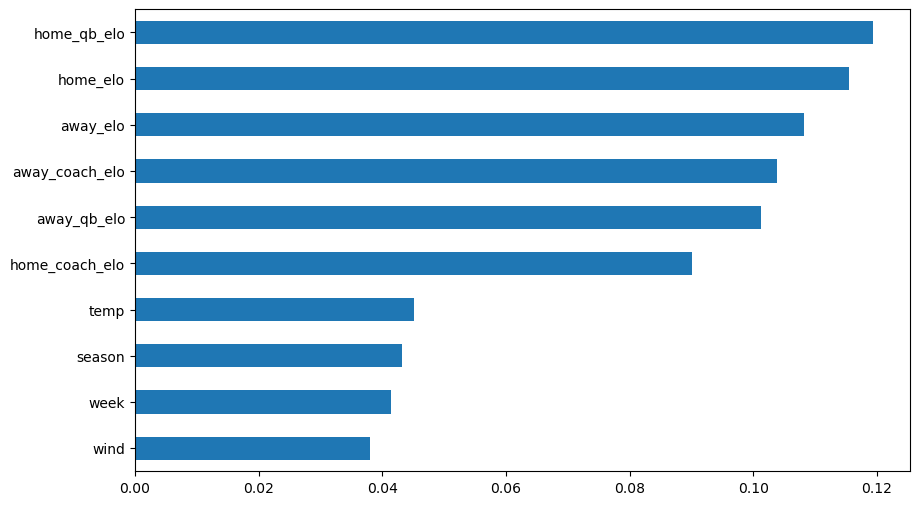

In [69]:
fi = model_rf.best_estimator_.feature_importances_

feature_importance = pd.Series(fi, index=features_base_train_elo_soft_enc.columns)
feature_importance.sort_values(ascending=False)[:10].plot(kind='barh', figsize=(10, 6)).invert_yaxis()

In [70]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = grid_log_one.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))                                             

-----LogReg-----
Best Parameter: {'C': 0.1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.63      0.43      0.51       520
           1       0.61      0.79      0.69       600

    accuracy                           0.62      1120
   macro avg       0.62      0.61      0.60      1120
weighted avg       0.62      0.62      0.61      1120



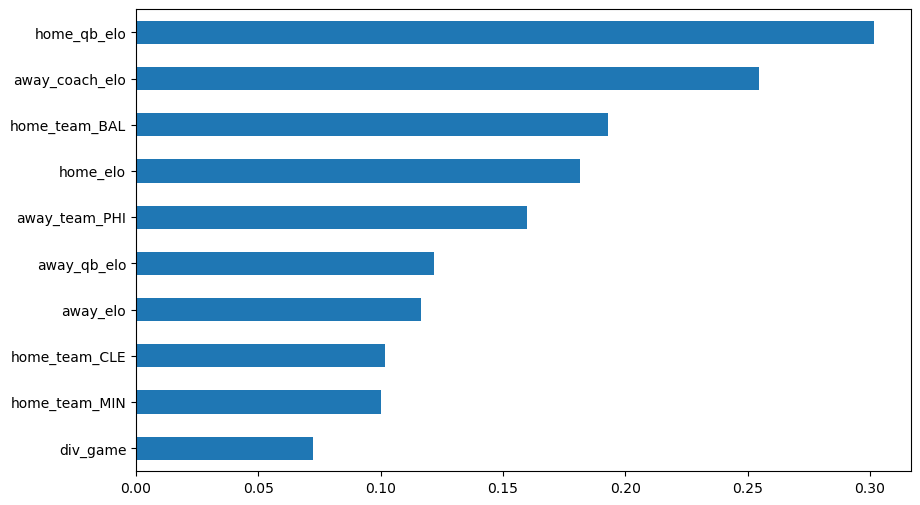

In [71]:
coefficients = grid_log_one.best_estimator_.coef_[0]
feature_importance = pd.Series(np.abs(coefficients), index=features_base_train_elo_soft_enc.columns)
#feature_importance = pd.DataFrame({'Feature': features_base_train_elo_soft_enc.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance[:10].plot(kind='barh', figsize=(10, 6)).invert_yaxis()

In [72]:
xgb = XGBClassifier(objective="binary:logistic", eval_metric="pre")

# Fit on Train Data
xgb.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = xgb.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----LogReg-----")
#print("Best Parameter: {}".format(xgb.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))    

-----LogReg-----
              precision    recall  f1-score   support

           0       0.57      0.45      0.50       520
           1       0.60      0.71      0.65       600

    accuracy                           0.59      1120
   macro avg       0.58      0.58      0.58      1120
weighted avg       0.58      0.59      0.58      1120



In [73]:
# Win probability:
# EA = 1/(1+10^((RH-RA)/400))
# EH = 1/(1+10^((RA-RH)/400))
# EA = Win probability away_team
# EH = Win probability home_team
# RA = Rating away_team
# RH = Rating home_team

In [74]:
# New Rating:
# New RA = Old RA + K * (SA-EA)
# New RH = Old RH + K * (SH-EH)
# SA = Actual Score Team A(Win = 1)
# SB = Actual Score Team B(Loose = 0)
# K determines approximatley how much a player rating can change after a single match
# in chess K = 32, but u can also use a formula for K. to keep it simple we copy 32 from chess
# e.g. if EA = 0,75 (75% probability to win)
# (1-0,5) = 0,25
# (0-0,5)
# New RA = 1500 + 32 * 0,5 = 1516
# New RH = 1500 + 32 * (-0,5) = 1484

In [75]:
## ---------- WEBCRAWLING ----------
#from bs4 import BeautifulSoup
#import requests

In [76]:
#website_url = "https://www.pro-football-reference.com/boxscores/202401130kan.htm"
#response = requests.get(website_url)
#print(response)
#soup = BeautifulSoup(response.text)

In [77]:
#table = soup.find(id="div_scoring")
#for stat in table.find_all("td"):
#    print(stat)

In [78]:
# binary prediction
# when win probability is about 50%+-5% predict tie

In [79]:
df_f_test.columns

Index(['season', 'month', 'week', 'weekday', 'starting_hour', 'game_type',
       'away_team', 'away_elo', 'home_team', 'home_elo', 'away_avg_points',
       'away_avg_points_allowed', 'home_avg_points', 'home_avg_points_allowed',
       'location', 'away_rest', 'home_rest', 'div_game', 'roof', 'surface',
       'temp', 'wind', 'away_qb', 'away_qb_elo', 'home_qb', 'home_qb_elo',
       'away_coach', 'away_coach_elo', 'home_coach', 'home_coach_elo',
       'referee', 'stadium', 'win'],
      dtype='object')

In [80]:
df_f_test = feature_eng(df)
df_points_test = df_f_test[['season', 'week', 'weekday', 'starting_hour', 'game_type',
                            'away_team', 'home_team', 'away_avg_points', 'away_avg_points_allowed', 
                            'home_avg_points', 'home_avg_points_allowed', 'location', 'away_rest', 
                            'home_rest', 'div_game', 'roof', 'surface', 'temp', 'wind', 'win']]

In [81]:
df_points_test.head()

,season,week,weekday,starting_hour,game_type,away_team,home_team,away_avg_points,away_avg_points_allowed,home_avg_points,home_avg_points_allowed,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,1,Sunday,13,REG,SF,ATL,0.0,0.0,0.0,0.0,Home,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,1,Sunday,13,REG,JAX,CLE,0.0,0.0,0.0,0.0,Home,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,1,Sunday,13,REG,IND,KC,0.0,0.0,0.0,0.0,Home,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,1,Sunday,13,REG,CHI,MIN,0.0,0.0,0.0,0.0,Home,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,1,Sunday,13,REG,TB,NE,0.0,0.0,0.0,0.0,Home,7,7,0,outdoors,grass,71.0,5.0,0


In [82]:
from sklearn.compose import ColumnTransformer

features_train_points, target_train_points, features_test_points, target_test_points = train_test_split(df_points_test)

# Split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_train_points.select_dtypes(include=[np.number]).columns
cat_cols = features_train_points.select_dtypes(exclude=[np.number]).columns

# Create columnTransformer
columnTransformer = ColumnTransformer([("std", StandardScaler(), num_cols),
                                       ("ohe", OneHotEncoder(), cat_cols)],
                                       remainder="passthrough")

features_train_points_array = columnTransformer.fit_transform(features_train_points).toarray()
col_names = []
for col in columnTransformer.get_feature_names_out():
    col_names.append(col[5:])
    
og_index = features_train_points.index    
features_train_points_ct = pd.DataFrame(features_train_points_array, columns=col_names, index=og_index)

features_test_points_array = columnTransformer.transform(features_test_points).toarray()
   
og_index = features_test_points.index    
features_test_points_ct = pd.DataFrame(features_test_points_array, columns=col_names, index=og_index)

In [83]:
from sklearn.compose import ColumnTransformer

features_train_points, target_train_points, features_test_points, target_test_points = train_test_split(df_points_test)

# Split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_train_points.select_dtypes(include=[np.number]).columns
cat_cols = features_train_points.select_dtypes(exclude=[np.number]).columns

# Create columnTransformer
columnTransformer = ColumnTransformer([("std", StandardScaler(), num_cols),
                                       ("ohe", OneHotEncoder(), cat_cols)],
                                       remainder="passthrough")

In [84]:
features_train_points_array = columnTransformer.fit_transform(features_train_points).toarray()
col_names = []
for col in columnTransformer.get_feature_names_out():
    col_names.append(col[5:])
    
og_index = features_train_points.index    
features_train_points_ct = pd.DataFrame(features_train_points_array, columns=col_names, index=og_index)

In [85]:
features_test_points_array = columnTransformer.transform(features_test_points).toarray()
   
og_index = features_test_points.index    
features_test_points_ct = pd.DataFrame(features_test_points_array, columns=col_names, index=og_index)

In [86]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_train_points_ct, target_train_points)
# Predict Target Test
target_test_points_ct_pred = grid_log_one.predict(features_test_points_ct)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_test_points, target_test_points_ct_pred))                                             

-----LogReg-----
Best Parameter: {'C': 1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.58      0.41      0.48       520
           1       0.59      0.75      0.66       600

    accuracy                           0.59      1120
   macro avg       0.59      0.58      0.57      1120
weighted avg       0.59      0.59      0.58      1120



In [87]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='f1',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_train_points_ct, target_train_points)
# Predict Target Test
target_test_points_ct_pred = model_rf.predict(features_test_points_ct)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_test_points, target_test_points_ct_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 33, 'min_samples_leaf': 62}
              precision    recall  f1-score   support

           0       0.59      0.22      0.32       520
           1       0.56      0.87      0.68       600

    accuracy                           0.57      1120
   macro avg       0.58      0.54      0.50      1120
weighted avg       0.58      0.57      0.51      1120



In [88]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_train_points_ct, target_train_points)
# Predict Target Test
target_test_points_ct_pred = model_rf.predict(features_test_points_ct)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_test_points, target_test_points_ct_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 25, 'min_samples_leaf': 7}
              precision    recall  f1-score   support

           0       0.58      0.38      0.46       520
           1       0.59      0.76      0.66       600

    accuracy                           0.59      1120
   macro avg       0.58      0.57      0.56      1120
weighted avg       0.58      0.59      0.57      1120



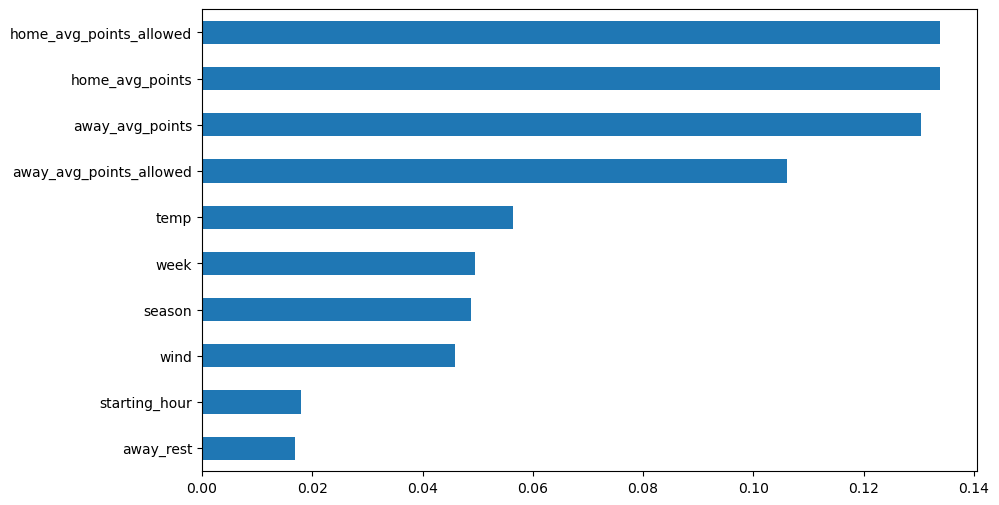

In [89]:
fi = model_rf.best_estimator_.feature_importances_

feature_importance = pd.Series(fi, index=features_test_points_ct.columns)
feature_importance.sort_values(ascending=False)[:10].plot(kind='barh', figsize=(10, 6)).invert_yaxis()

In [90]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_train_points_ct, target_train_points)
# Predict Target Test
target_test_points_ct_pred = model_rf.predict(features_test_points_ct)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_test_points, target_test_points_ct_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 154, 'min_samples_leaf': 1}
              precision    recall  f1-score   support

           0       0.53      0.44      0.48       520
           1       0.58      0.66      0.62       600

    accuracy                           0.56      1120
   macro avg       0.55      0.55      0.55      1120
weighted avg       0.56      0.56      0.55      1120



In [91]:
search_space_rf = {'max_depth': range(1,30)}

model_dt = GridSearchCV(estimator=DecisionTreeClassifier(),
                                  param_grid=search_space_rf,
                                  scoring='precision',
                                  cv=5,
                                  n_jobs=-1)

model_dt.fit(features_train_points_ct, target_train_points)
target_test_points_ct_pred = model_dt.predict(features_test_points_ct)
print("-----DecisionTree-----")
print("Best Parameter: {}".format(model_dt.best_params_))
print(classification_report(target_test_points, target_test_points_ct_pred))

-----DecisionTree-----
Best Parameter: {'max_depth': 4}
              precision    recall  f1-score   support

           0       0.55      0.56      0.55       520
           1       0.61      0.61      0.61       600

    accuracy                           0.58      1120
   macro avg       0.58      0.58      0.58      1120
weighted avg       0.58      0.58      0.58      1120



In [92]:
# Now combine elo and average score

In [93]:
df_all_test = feature_eng(df)
df_all_test.columns

Index(['season', 'month', 'week', 'weekday', 'starting_hour', 'game_type',
       'away_team', 'away_elo', 'home_team', 'home_elo', 'away_avg_points',
       'away_avg_points_allowed', 'home_avg_points', 'home_avg_points_allowed',
       'location', 'away_rest', 'home_rest', 'div_game', 'roof', 'surface',
       'temp', 'wind', 'away_qb', 'away_qb_elo', 'home_qb', 'home_qb_elo',
       'away_coach', 'away_coach_elo', 'home_coach', 'home_coach_elo',
       'referee', 'stadium', 'win'],
      dtype='object')

In [94]:
df_all = df_all_test[['season', 'month', 'week', 'weekday', 'starting_hour', 'game_type',
                     'away_team', 'away_elo', 'home_team', 'home_elo', 'away_avg_points',
                     'away_avg_points_allowed', 'home_avg_points', 'home_avg_points_allowed',
                     'location', 'away_rest', 'home_rest', 'div_game', 'roof', 'surface',
                     'temp', 'wind', 'away_qb_elo', 'home_qb_elo', 'away_coach_elo', 'home_coach_elo', 'win']]

In [95]:
features_train_all, target_train_all, features_test_all, target_test_all = train_test_split(df_all)



# Split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_train_all.select_dtypes(include=[np.number]).columns
cat_cols = features_train_all.select_dtypes(exclude=[np.number]).columns

# Create columnTransformer
columnTransformer = ColumnTransformer([("std", StandardScaler(), num_cols),
                                       ("ohe", OneHotEncoder(), cat_cols)],
                                       remainder="passthrough")

features_train_all_array = columnTransformer.fit_transform(features_train_all).toarray()

col_names = []
for col in columnTransformer.get_feature_names_out():
    col_names.append(col[5:])
    
og_index = features_train_all.index    
features_train_all_ct = pd.DataFrame(features_train_all_array, columns=col_names, index=og_index)

features_test_all_array = columnTransformer.transform(features_test_all).toarray()
   
og_index = features_test_all.index    
features_test_all_ct = pd.DataFrame(features_test_all_array, columns=col_names, index=og_index)

In [104]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_train_all_ct, target_train_all)
# Predict Target Test
target_test_all_pred = grid_log_one.predict(features_test_all_ct)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_test_all, target_test_all_pred))                                            

-----LogReg-----
Best Parameter: {'C': 1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.59      0.42      0.49       520
           1       0.60      0.75      0.67       600

    accuracy                           0.60      1120
   macro avg       0.60      0.58      0.58      1120
weighted avg       0.60      0.60      0.58      1120



In [105]:
search_space_rf = {'max_depth': range(1,15)}

model_dt = GridSearchCV(estimator=DecisionTreeClassifier(),
                                  param_grid=search_space_rf,
                                  scoring='precision',
                                  cv=5,
                                  n_jobs=-1)

model_dt.fit(features_train_all_ct, target_train_all)
target_test_all_pred = model_dt.predict(features_test_all_ct)
print("-----DecisionTree-----")
print("Best Parameter: {}".format(model_dt.best_params_))
print(classification_report(target_test_all, target_test_all_pred))

-----DecisionTree-----
Best Parameter: {'max_depth': 4}
              precision    recall  f1-score   support

           0       0.58      0.41      0.48       520
           1       0.59      0.74      0.66       600

    accuracy                           0.59      1120
   macro avg       0.58      0.57      0.57      1120
weighted avg       0.58      0.59      0.57      1120



In [98]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf_f1 = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='f1',
                                                         cv=5,
                                                         n_jobs=-1)
model_rf_acc = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
model_rf_pre = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf_f1.fit(features_train_all_ct, target_train_all)
# Predict Target Test
target_test_all_pred_f1 = model_rf_f1.predict(features_test_all_ct)
# Fit on Train Data
model_rf_acc.fit(features_train_all_ct, target_train_all)
# Predict Target Test
target_test_all_pred_acc = model_rf_acc.predict(features_test_all_ct)
# Fit on Train Data
model_rf_pre.fit(features_train_all_ct, target_train_all)
# Predict Target Test
target_test_all_pred_pre = model_rf_pre.predict(features_test_all_ct)
                                            
# Print Metrics
print("-----RandomForest F1-----")
print("Best Parameter: {}".format(model_rf_f1.best_params_))
print(classification_report(target_test_all, target_test_all_pred_f1))
# Print Metrics
print("-----RandomForest Accuracy-----")
print("Best Parameter: {}".format(model_rf_acc.best_params_))
print(classification_report(target_test_all, target_test_all_pred_acc))
# Print Metrics
print("-----RandomForest Precision-----")
print("Best Parameter: {}".format(model_rf_pre.best_params_))
print(classification_report(target_test_all, target_test_all_pred_pre))

-----RandomForest F1-----
Best Parameter: {'max_depth': 154, 'min_samples_leaf': 500}
              precision    recall  f1-score   support

           0       0.64      0.16      0.26       520
           1       0.56      0.92      0.70       600

    accuracy                           0.57      1120
   macro avg       0.60      0.54      0.48      1120
weighted avg       0.60      0.57      0.49      1120

-----RandomForest Accuracy-----
Best Parameter: {'max_depth': 71, 'min_samples_leaf': 15}
              precision    recall  f1-score   support

           0       0.60      0.37      0.45       520
           1       0.59      0.79      0.68       600

    accuracy                           0.59      1120
   macro avg       0.60      0.58      0.56      1120
weighted avg       0.59      0.59      0.57      1120

-----RandomForest Precision-----
Best Parameter: {'max_depth': 71, 'min_samples_leaf': 1}
              precision    recall  f1-score   support

           0       0.54  

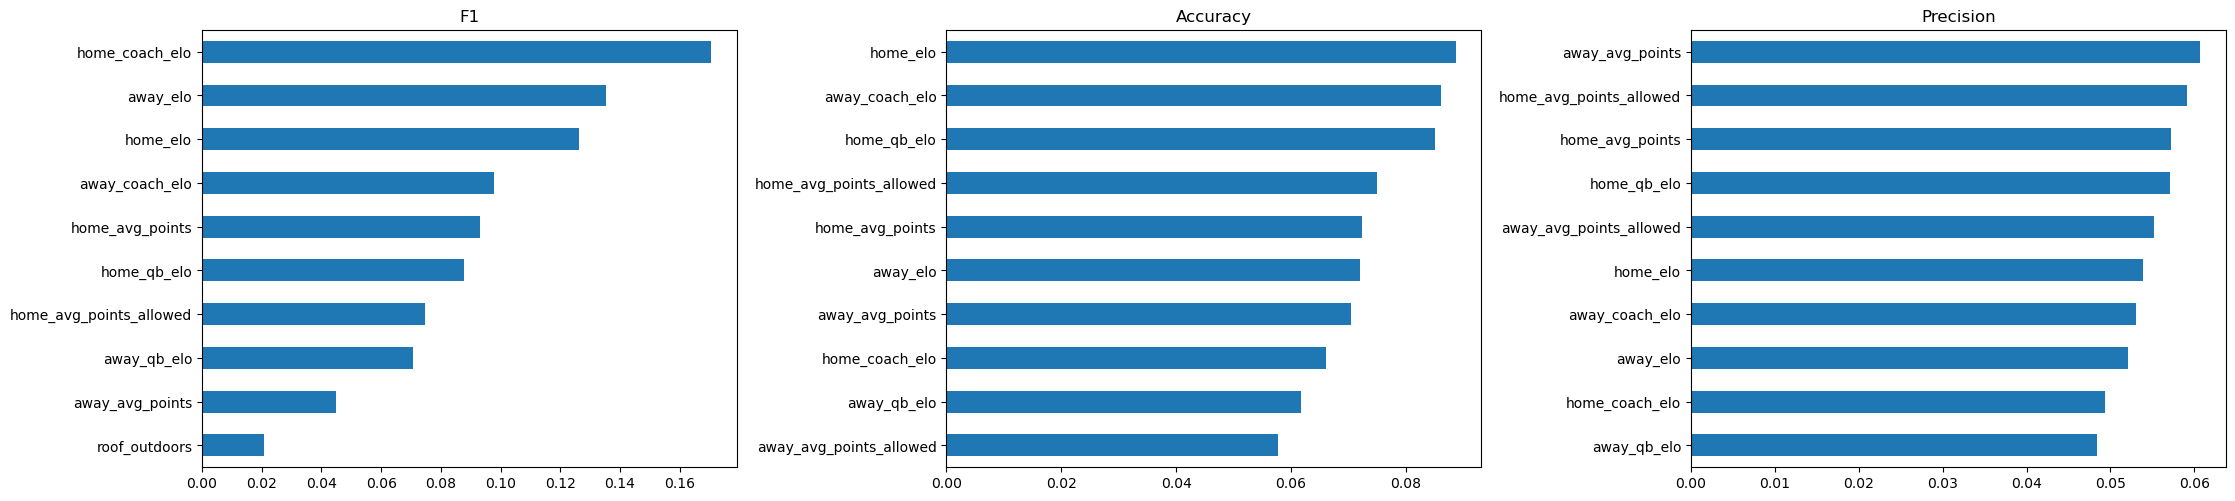

In [99]:
fig, axs = plt.subplots(ncols=3, figsize=(24, 8))
fig.tight_layout(pad=12)

fi_f1 = model_rf_f1.best_estimator_.feature_importances_
feature_importance_f1 = pd.Series(fi_f1, index=features_test_all_ct.columns)
feature_importance_f1.sort_values(ascending=False)[:10].plot(kind='barh', title="F1", ax=axs[0]).invert_yaxis()

fi_acc = model_rf_acc.best_estimator_.feature_importances_
feature_importance_acc = pd.Series(fi_acc, index=features_test_all_ct.columns)
feature_importance_acc.sort_values(ascending=False)[:10].plot(kind='barh', title="Accuracy", ax=axs[1]).invert_yaxis()

fi_pre = model_rf_pre.best_estimator_.feature_importances_
feature_importance_pre = pd.Series(fi_pre, index=features_test_all_ct.columns)
feature_importance_pre.sort_values(ascending=False)[:10].plot(kind='barh', title="Precision", ax=axs[2]).invert_yaxis()

In [100]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

min_features_to_select = 64  # Minimum number of features to consider
clf = grid_log_one.best_estimator_
cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv.fit(features_train_all_ct, target_train_all)

print("Optimal number of features: {}".format(rfecv.n_features_))
print("Optimal features: {}".format(rfecv.get_feature_names_out()))

Optimal number of features: 66
Optimal features: ['month' 'away_elo' 'home_elo' 'away_avg_points' 'away_avg_points_allowed'
 'home_avg_points' 'home_avg_points_allowed' 'away_rest' 'div_game'
 'away_qb_elo' 'home_qb_elo' 'away_coach_elo' 'home_coach_elo'
 'weekday_Friday' 'weekday_Monday' 'weekday_Thursday' 'game_type_SB'
 'game_type_WC' 'away_team_ARI' 'away_team_ATL' 'away_team_BUF'
 'away_team_CAR' 'away_team_CIN' 'away_team_CLE' 'away_team_DET'
 'away_team_GB' 'away_team_HOU' 'away_team_IND' 'away_team_JAX'
 'away_team_LV' 'away_team_MIN' 'away_team_NE' 'away_team_NO'
 'away_team_NYG' 'away_team_NYJ' 'away_team_PHI' 'away_team_PIT'
 'away_team_SF' 'away_team_TB' 'away_team_TEN' 'away_team_WAS'
 'home_team_ARI' 'home_team_BAL' 'home_team_CLE' 'home_team_DEN'
 'home_team_DET' 'home_team_GB' 'home_team_IND' 'home_team_JAX'
 'home_team_KC' 'home_team_LA' 'home_team_LV' 'home_team_MIA'
 'home_team_MIN' 'home_team_NE' 'home_team_NYG' 'home_team_PIT'
 'home_team_SEA' 'home_team_SF' 'home_

In [101]:
# Predict Target Test
target_test_all_pred_acc = rfecv.predict(features_test_all_ct)
                                        
# Print Metrics
print("-----LogReg with RFECV-----")
print("Best Parameter: {}".format(grid_log_one.best_estimator_))
print(classification_report(target_test_all, target_test_all_pred_acc))

-----LogReg with RFECV-----
Best Parameter: LogisticRegression(C=1, max_iter=1000, penalty='l1', solver='saga')
              precision    recall  f1-score   support

           0       0.59      0.39      0.47       520
           1       0.59      0.77      0.67       600

    accuracy                           0.59      1120
   macro avg       0.59      0.58      0.57      1120
weighted avg       0.59      0.59      0.58      1120

